In [33]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf


In [37]:
source_dir = "Documents/Agricultural-crops"
base_dir = "Documents/dataset"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Vérifions le nombre de classes
classes = sorted(os.listdir(train_dir))
num_classes = len(classes)
print(f"✅ Nombre de classes détectées : {num_classes}")


✅ Nombre de classes détectées : 30


Found 569 images belonging to 30 classes.
Found 122 images belonging to 30 classes.
Found 138 images belonging to 30 classes.


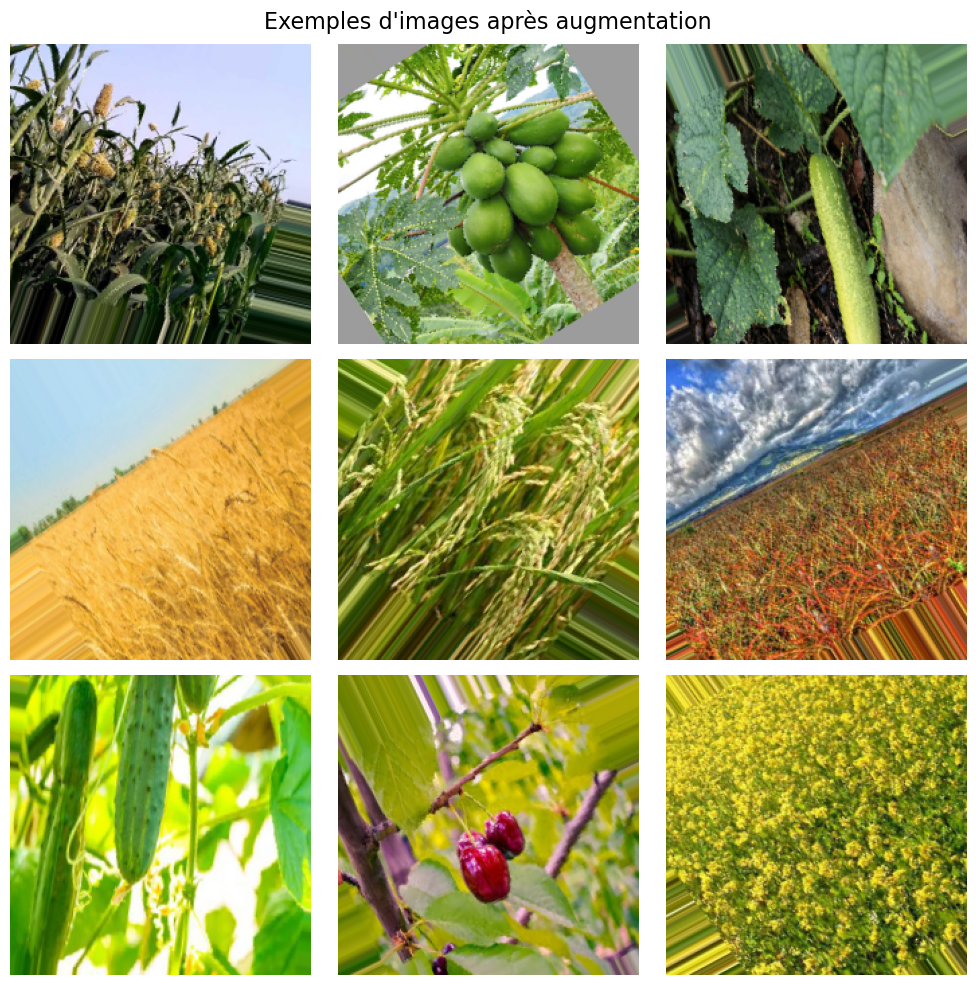

In [89]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# Générateurs de données
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, 
    target_size=(224, 224), 
    batch_size=32, 
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir, 
    target_size=(224, 224), 
    batch_size=32, 
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir, 
    target_size=(224, 224), 
    batch_size=32, 
    class_mode='categorical', 
    shuffle=False
)

#on affiche les images aleatoirement
images, labels = next(train_generator)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.suptitle("Exemples d'images après augmentation", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
#  Définir le modèle avec MobileNetV2
num_classes = train_generator.num_classes
base_model.trainable = True

#degel
fine_tune_at = 100  
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # On gèle le backbone pour commencer

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


In [ ]:
#  Compiler et entraîner 
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Gestion des classes déséquilibrées
labels = train_generator.classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stopping],
    class_weight=class_weight_dict
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.7524 - loss: 0.8717 - val_accuracy: 0.6311 - val_loss: 1.2187
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7922 - loss: 0.7170 - val_accuracy: 0.6721 - val_loss: 1.1624
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.7880 - loss: 0.7162 - val_accuracy: 0.6721 - val_loss: 1.0882
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8166 - loss: 0.5944 - val_accuracy: 0.6393 - val_loss: 1.1678
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8087 - loss: 0.5958 - val_accuracy: 0.6967 - val_loss: 1.0951
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8198 - loss: 0.5309 - val_accuracy: 0.6557 - val_loss: 1.1469
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8343 - loss: 0.5032 - val_accuracy: 0.6967 - val_loss: 1.1362
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8504 - loss: 0.4610 - val_accuracy: 0.6885 - val_loss:

In [ ]:
# Évaluation finale
loss, acc = model.evaluate(test_generator)
print(f"\n✅ Accuracy finale sur le test set : {acc*100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 718ms/step - accuracy: 0.7407 - loss: 1.0078

✅ Accuracy finale sur le test set : 73.91%


In [ ]:

model.save("model_final.h5")
print("✅ Modèle sauvegardé sous 'model_final.h5'")


✅ Modèle sauvegardé sous 'model_final.h5'


In [ ]:
import json

# Obtenir les correspondances des classes
class_indices = train_generator.class_indices  # ex: {'banana': 0, 'tomato': 1, ...}

# Sauvegarde dans un fichier JSON
with open("class_indices.json", "w") as f:
    json.dump(class_indices, f)

print("✅ Fichier class_indices.json créé")


✅ Fichier class_indices.json créé
